# Phân tích Khám phá Dữ liệu (EDA) - Dự báo Khách hàng Rời bỏ (Customer Churn)

Notebook này thực hiện các công đoạn EDA đầu tiên cho bài toán phân loại Churn:
1. **Thiết lập mốc thời gian $T = \text{30/06/2022}$**.
2. **Dán nhãn Churn/Active** dựa trên 180 ngày tiếp theo (từ 01/07/2022 đến 27/12/2022):
   - $y = 1$ (Churn): Khách hàng không phát sinh bất kỳ đơn hàng nào trong 180 ngày tiếp theo.
   - $y = 0$ (Active): Khách hàng có ít nhất 1 đơn hàng trong 180 ngày tiếp theo.
3. **Tính toán đặc trưng tại thời điểm $T$**:
   - **Recency**: Số ngày kể từ lần mua cuối cùng trước $T$ đến $T$.
   - **Frequency**: Tổng số đơn hàng trước hoặc bằng $T$.
4. **Trực quan hóa và So sánh phân phối** của Recency và Frequency giữa hai nhóm Churn và Active bằng Boxplot và Density Plot.

## 1. Khởi tạo Môi trường & Tải dữ liệu

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = r'./datathon-2026-round-1'
print('Thư viện đã sẵn sàng!')

Thư viện đã sẵn sàng!


In [21]:
# Đọc dữ liệu đơn hàng và khách hàng
df_orders = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
df_customers = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'), parse_dates=['signup_date'])
print(f'Số lượng đơn hàng: {df_orders.shape[0]:,}')
print(f'Số lượng khách hàng: {df_customers.shape[0]:,}')

Số lượng đơn hàng: 646,945
Số lượng khách hàng: 121,930


## 2. Xác định Khung thời gian & Gắn nhãn Churn

Chúng ta chọn thời điểm quan sát **$T = \text{30/06/2022}$**.
- Khách hàng mục tiêu: Những người đã từng có ít nhất 1 đơn hàng trước hoặc bằng $T$ (Frequency $\ge 1$).
- Khoảng thời gian dán nhãn (Target Window): 180 ngày kể từ sau $T$, tức là từ **01/07/2022 đến 27/12/2022**.

In [22]:
T = pd.to_datetime('2022-06-30')
target_end_date = T + pd.Timedelta(days=180)

print(f'Mốc thời gian T: {T.date()}')
print(f'Khoảng Target Window: Từ { (T + pd.Timedelta(days=1)).date() } đến { target_end_date.date() }')

Mốc thời gian T: 2022-06-30
Khoảng Target Window: Từ 2022-07-01 đến 2022-12-27


In [23]:
# Chia dữ liệu orders thành 2 giai đoạn: Trước T (Features) và Sau T (Target)
df_orders_before = df_orders[df_orders['order_date'] <= T]
df_orders_after = df_orders[(df_orders['order_date'] > T) & (df_orders['order_date'] <= target_end_date)]

print(f'Số lượng đơn hàng trước T (để tính Recency, Frequency): {df_orders_before.shape[0]:,}')
print(f'Số lượng đơn hàng sau T (để gán nhãn Churn): {df_orders_after.shape[0]:,}')

Số lượng đơn hàng trước T (để tính Recency, Frequency): 631,706
Số lượng đơn hàng sau T (để gán nhãn Churn): 14,752


## 3. Tính toán Recency, Frequency & Gắn nhãn Churn cho từng khách hàng

- **Recency**: $T$ - Ngày đặt hàng cuối cùng trước $T$ (đơn vị: ngày).
- **Frequency**: Tổng số đơn hàng trước hoặc bằng $T$ (mỗi đơn tương ứng với 1 dòng trong `orders.csv` vì order_id là duy nhất).
- **Churn ($y=1$)**: Nếu khách hàng KHÔNG xuất hiện trong tập `df_orders_after`.
- **Active ($y=0$)**: Nếu khách hàng CÓ xuất hiện trong tập `df_orders_after`.

In [24]:
# 1. Tính toán Recency và Frequency trước T cho từng khách hàng
cust_stats = df_orders_before.groupby('customer_id').agg(
    last_order_date=('order_date', 'max'),
    frequency=('order_id', 'count')
).reset_index()

cust_stats['recency'] = (T - cust_stats['last_order_date']).dt.days
print(f'Số lượng khách hàng đã từng mua trước T: {cust_stats.shape[0]:,}')

Số lượng khách hàng đã từng mua trước T: 89,721


In [25]:
# 2. Xác định danh sách khách hàng Active trong Target Window
active_customers = set(df_orders_after['customer_id'].unique())

# 3. Gán nhãn Churn
cust_stats['churn'] = cust_stats['customer_id'].apply(lambda x: 1 if x not in active_customers else 0)
cust_stats['churn_label'] = cust_stats['churn'].map({0: 'Active (y=0)', 1: 'Churn (y=1)'})

# Thống kê tỷ lệ Churn
churn_counts = cust_stats['churn'].value_counts()
churn_pct = cust_stats['churn'].value_counts(normalize=True) * 100

print('=== THỐNG KÊ TỶ LỆ CHURN ===')
for val, count in churn_counts.items():
    label = 'Churn (y=1)' if val == 1 else 'Active (y=0)'
    print(f'{label}: {count:,} khách hàng ({churn_pct[val]:.2f}%)')

=== THỐNG KÊ TỶ LỆ CHURN ===
Churn (y=1): 77,967 khách hàng (86.90%)
Active (y=0): 11,754 khách hàng (13.10%)


## 4. Phân tích Phân phối Recency & Frequency theo nhóm Churn/Active

Chúng ta sẽ so sánh sự khác biệt về hành vi quá khứ (Recency, Frequency) giữa hai nhóm khách hàng sau này sẽ Churn hoặc tiếp tục Active.

In [26]:
# Thống kê mô tả chi tiết
print('=== THỐNG KÊ MÔ TẢ RECENCY ===')
display(cust_stats.groupby('churn')['recency'].describe())

print('\n=== THỐNG KÊ MÔ TẢ FREQUENCY ===')
display(cust_stats.groupby('churn')['frequency'].describe())

=== THỐNG KÊ MÔ TẢ RECENCY ===


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,11754.0,619.572146,695.872804,0.0,93.0,368.0,897.5,3620.0
1,77967.0,1256.190735,986.882021,0.0,380.0,1107.0,1916.0,3648.0



=== THỐNG KÊ MÔ TẢ FREQUENCY ===


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,11754.0,14.880807,12.302437,1.0,6.0,12.0,20.0,103.0
1,77967.0,5.858851,6.974460,1.0,1.0,3.0,8.0,107.0


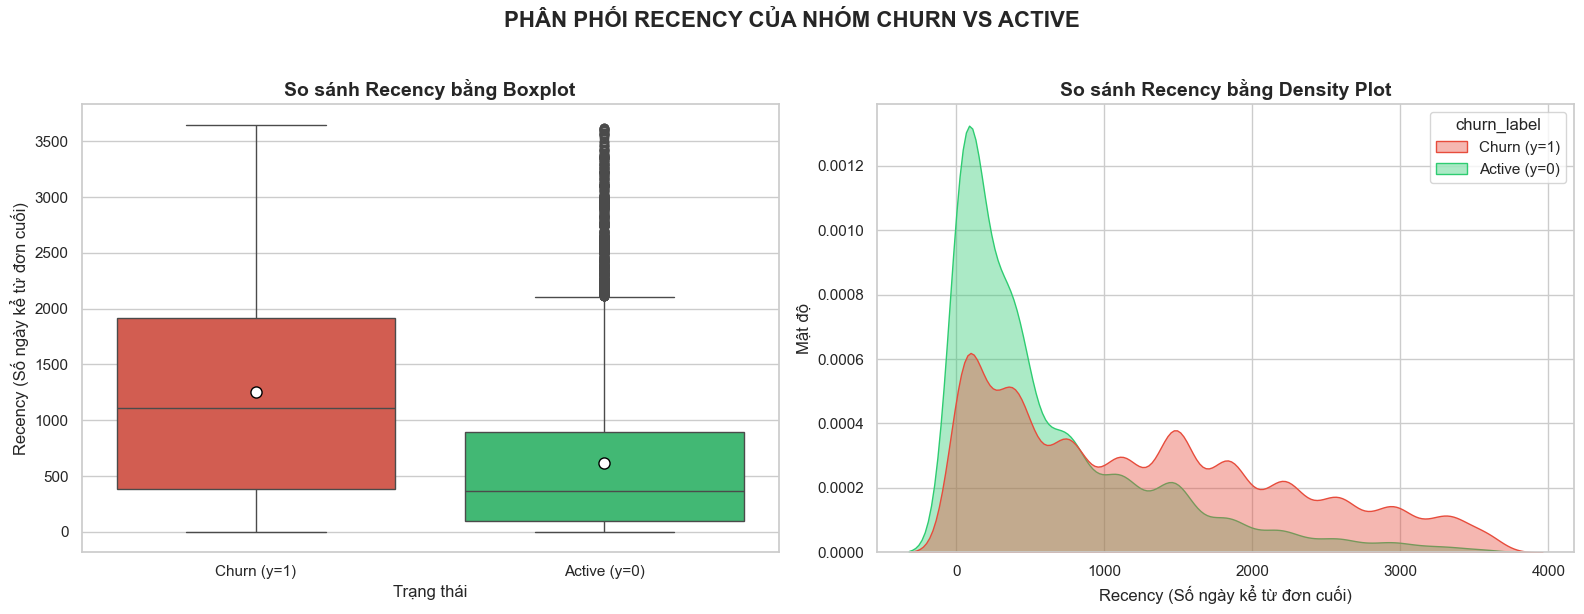

In [27]:
# Vẽ biểu đồ so sánh Recency
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Recency
sns.boxplot(
    data=cust_stats, x='churn_label', y='recency', ax=axes[0],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[0].set_title('So sánh Recency bằng Boxplot', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Trạng thái', fontsize=12)
axes[0].set_ylabel('Recency (Số ngày kể từ đơn cuối)', fontsize=12)

# Density Plot Recency
sns.kdeplot(
    data=cust_stats, x='recency', hue='churn_label', fill=True,
    common_norm=False, palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, alpha=0.4, ax=axes[1]
)
axes[1].set_title('So sánh Recency bằng Density Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recency (Số ngày kể từ đơn cuối)', fontsize=12)
axes[1].set_ylabel('Mật độ', fontsize=12)

plt.suptitle('PHÂN PHỐI RECENCY CỦA NHÓM CHURN VS ACTIVE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

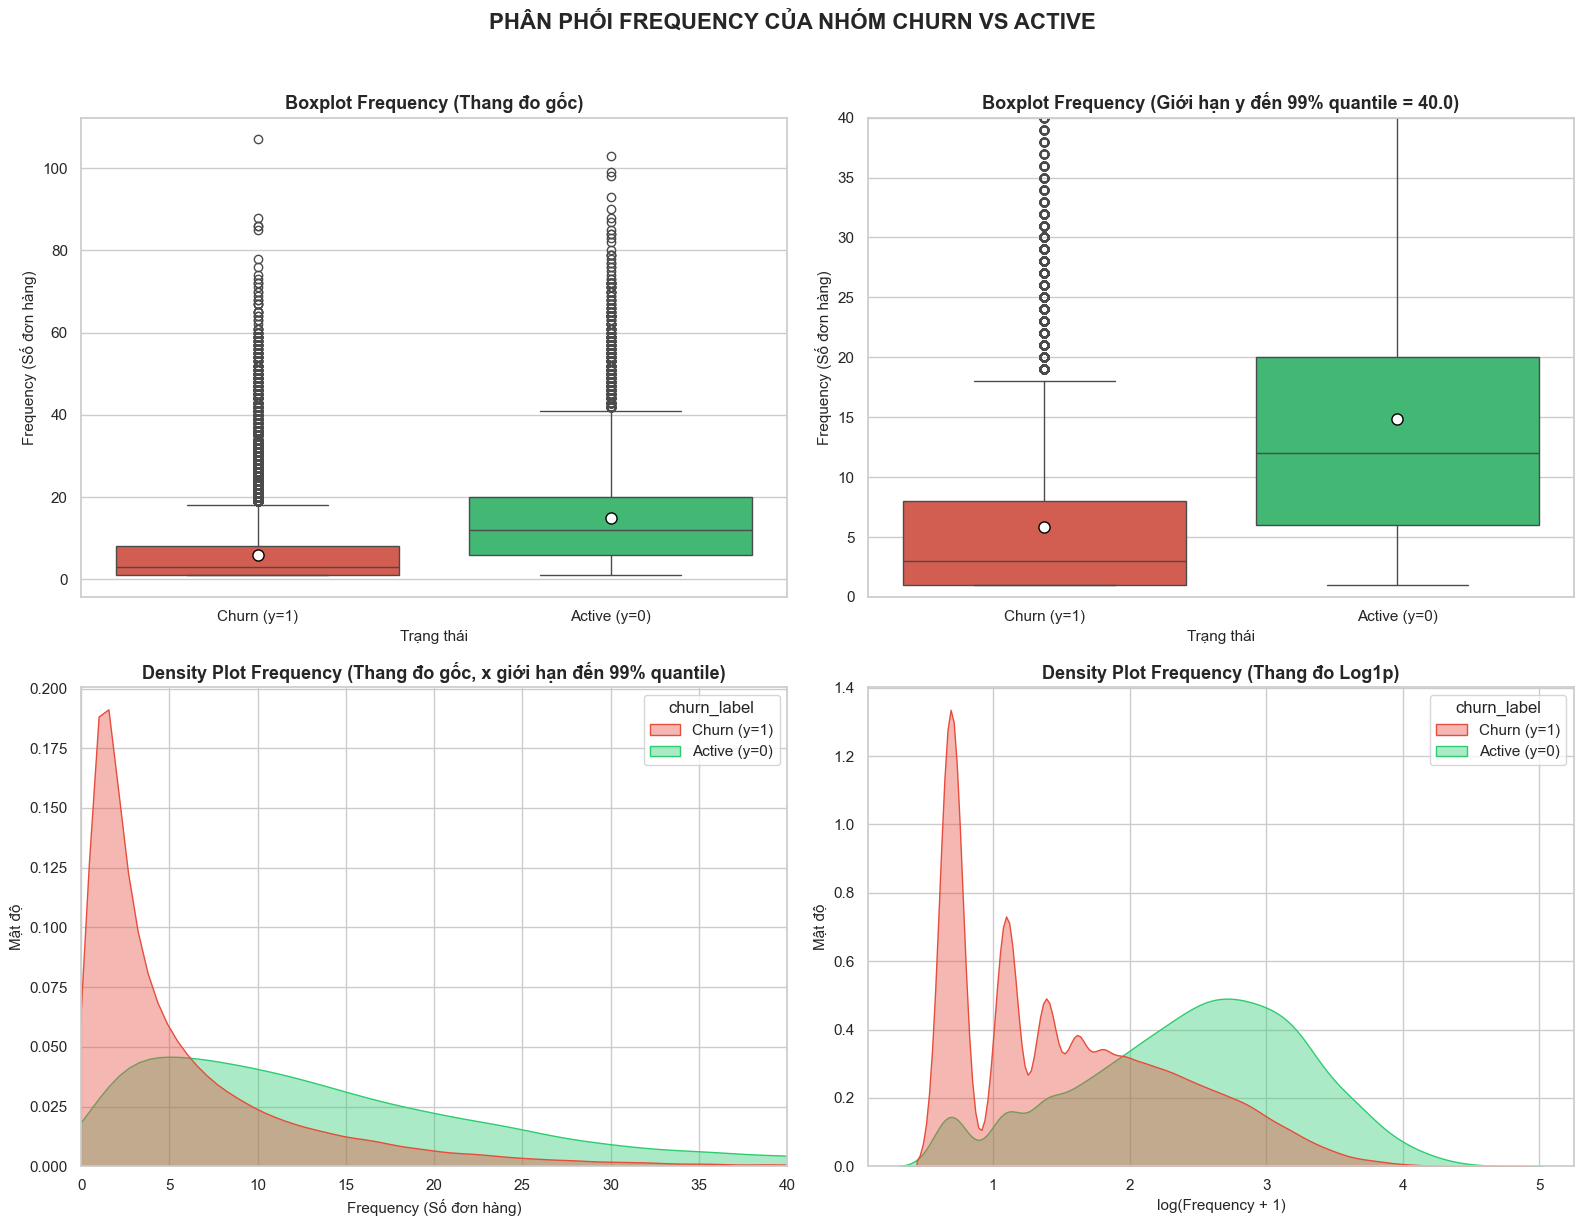

In [28]:
# Vẽ biểu đồ so sánh Frequency
# Lưu ý: Frequency thường bị lệch phải (skewed) rất mạnh vì có một số ít khách hàng mua cực nhiều.
# Do đó chúng ta sẽ vẽ cả thang đo gốc và thang đo Log để dễ quan sát.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot Frequency (Gốc)
sns.boxplot(
    data=cust_stats, x='churn_label', y='frequency', ax=axes[0, 0],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[0, 0].set_title('Boxplot Frequency (Thang đo gốc)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Trạng thái', fontsize=11)
axes[0, 0].set_ylabel('Frequency (Số đơn hàng)', fontsize=11)

# 2. Boxplot Frequency (Log Scale hoặc giới hạn trục y)
# Giới hạn trục y ở phân vị 99% để loại bỏ outlier hiển thị
q99 = cust_stats['frequency'].quantile(0.99)
sns.boxplot(
    data=cust_stats, x='churn_label', y='frequency', ax=axes[0, 1],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[0, 1].set_ylim(0, q99)
axes[0, 1].set_title(f'Boxplot Frequency (Giới hạn y đến 99% quantile = {q99})', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Trạng thái', fontsize=11)
axes[0, 1].set_ylabel('Frequency (Số đơn hàng)', fontsize=11)

# 3. Density Plot Frequency (Gốc)
sns.kdeplot(
    data=cust_stats, x='frequency', hue='churn_label', fill=True,
    common_norm=False, palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, alpha=0.4, ax=axes[1, 0]
)
axes[1, 0].set_xlim(0, q99)
axes[1, 0].set_title('Density Plot Frequency (Thang đo gốc, x giới hạn đến 99% quantile)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Frequency (Số đơn hàng)', fontsize=11)
axes[1, 0].set_ylabel('Mật độ', fontsize=11)

# 4. Density Plot Frequency (Log1p)
cust_stats['log_frequency'] = np.log1p(cust_stats['frequency'])
sns.kdeplot(
    data=cust_stats, x='log_frequency', hue='churn_label', fill=True,
    common_norm=False, palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, alpha=0.4, ax=axes[1, 1]
)
axes[1, 1].set_title('Density Plot Frequency (Thang đo Log1p)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('log(Frequency + 1)', fontsize=11)
axes[1, 1].set_ylabel('Mật độ', fontsize=11)

plt.suptitle('PHÂN PHỐI FREQUENCY CỦA NHÓM CHURN VS ACTIVE', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Khảo sát các Giả thuyết về Hành vi (Giao trễ, Trả hàng, Đánh giá)

Để đào sâu hơn các yếu tố có thể ảnh hưởng đến quyết định rời bỏ của khách hàng, chúng ta sẽ kiểm nghiệm 3 giả thuyết sau:
1. **Giả thuyết 1**: Đơn hàng bị giao trễ (`delivery_date` trừ `ship_date` quá lớn) tỷ lệ thuận với tỷ lệ Churn.
2. **Giả thuyết 2**: Khách hàng từng có đơn hàng bị trả lại (`returns.csv`) có xu hướng Churn cao hơn.
3. **Giả thuyết 3**: Điểm số đánh giá (`rating` trong `reviews.csv`) thấp sẽ là ngòi nổ thúc đẩy Churn.

In [29]:
# Tải thêm các bảng dữ liệu bổ sung
df_shipments = pd.read_csv(os.path.join(DATA_DIR, 'shipments.csv'), parse_dates=['ship_date', 'delivery_date'])
df_returns = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'), parse_dates=['return_date'])
df_reviews = pd.read_csv(os.path.join(DATA_DIR, 'reviews.csv'), parse_dates=['review_date'])

# 1. Tính toán thời gian giao hàng (Shipments) cho các đơn hàng trước T
df_ship_orders = df_orders_before.merge(df_shipments, on='order_id', how='inner')
df_ship_orders['ship_duration'] = (df_ship_orders['delivery_date'] - df_ship_orders['ship_date']).dt.days

# Tính giá trị trung bình và tỷ lệ đơn giao trễ (>= 6 ngày) cho từng khách hàng
cust_ship = df_ship_orders.groupby('customer_id').agg(
    avg_ship_duration=('ship_duration', 'mean'),
    pct_late_ship=('ship_duration', lambda x: (x >= 6).mean())
).reset_index()

cust_stats = cust_stats.merge(cust_ship, on='customer_id', how='left')

# 2. Kiểm định Trả hàng (Returns) trước T
df_returns_before = df_returns[df_returns['return_date'] <= T]
df_order_returns = df_orders_before.merge(df_returns_before, on='order_id', how='inner')
returned_cust = set(df_order_returns['customer_id'].unique())
cust_stats['has_return'] = cust_stats['customer_id'].apply(lambda x: 1 if x in returned_cust else 0)
cust_stats['has_return_label'] = cust_stats['has_return'].map({0: 'Không trả hàng', 1: 'Từng trả hàng'})

# 3. Kiểm định Đánh giá (Reviews) trước T
df_reviews_before = df_reviews[df_reviews['review_date'] <= T]
cust_reviews = df_reviews_before.groupby('customer_id').agg(
    avg_rating=('rating', 'mean')
).reset_index()
cust_stats = cust_stats.merge(cust_reviews, on='customer_id', how='left')

print('Tích hợp các bảng phụ thành công!')

Tích hợp các bảng phụ thành công!


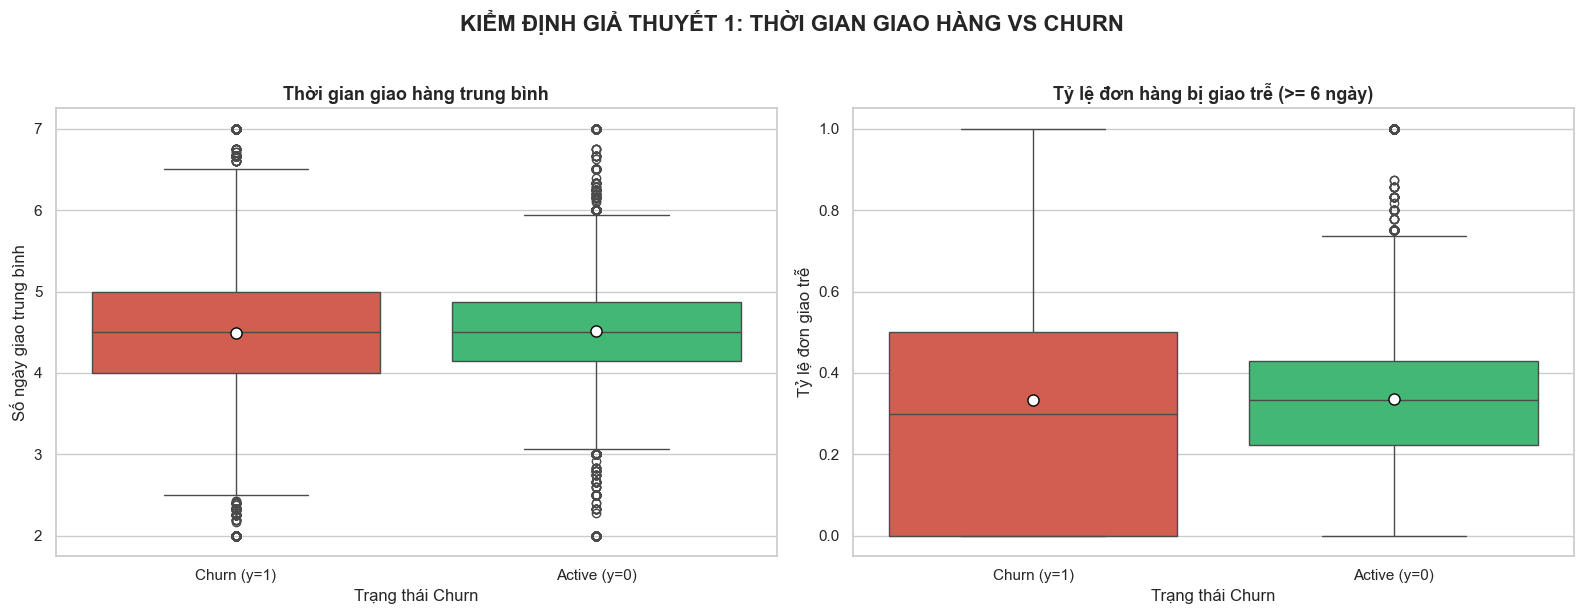

Bảng mô tả chi tiết thời gian giao hàng:


avg_ship_duration                                                 \
                         count      mean       std  min       25%  50%    75%   
churn_label                                                                     
Active (y=0)           11683.0  4.511074  0.714795  2.0  4.142857  4.5  4.875   
Churn (y=1)            75075.0  4.494627  1.169116  2.0  4.000000  4.5  5.000   

                  pct_late_ship                                               \
              max         count      mean       std  min       25%       50%   
churn_label                                                                    
Active (y=0)  7.0       11683.0  0.336029  0.199734  0.0  0.222222  0.333333   
Churn (y=1)   7.0       75075.0  0.332905  0.322905  0.0  0.000000  0.300000   

                             
                   75%  max  
churn_label                  
Active (y=0)  0.428571  1.0  
Churn (y=1)   0.500000  1.0

In [30]:
# --- KIỂM ĐỊNH GIẢ THUYẾT 1: GIAO TRỄ VS CHURN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=cust_stats.dropna(subset=['avg_ship_duration']),
    x='churn_label', y='avg_ship_duration', ax=axes[0],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[0].set_title('Thời gian giao hàng trung bình', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trạng thái Churn')
axes[0].set_ylabel('Số ngày giao trung bình')

sns.boxplot(
    data=cust_stats.dropna(subset=['pct_late_ship']),
    x='churn_label', y='pct_late_ship', ax=axes[1],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[1].set_title('Tỷ lệ đơn hàng bị giao trễ (>= 6 ngày)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trạng thái Churn')
axes[1].set_ylabel('Tỷ lệ đơn giao trễ')

plt.suptitle('KIỂM ĐỊNH GIẢ THUYẾT 1: THỜI GIAN GIAO HÀNG VS CHURN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Bảng mô tả chi tiết thời gian giao hàng:')
display(cust_stats.groupby('churn_label')[['avg_ship_duration', 'pct_late_ship']].describe())

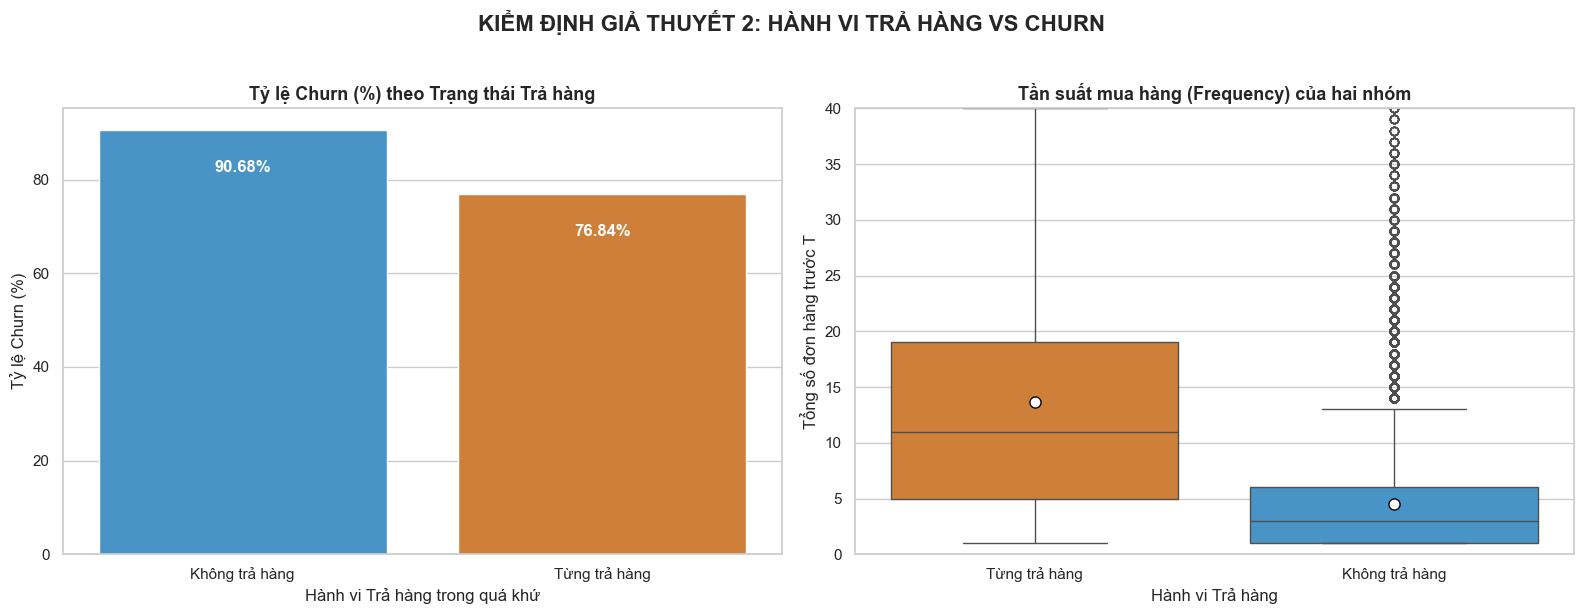

Tỷ lệ Churn phân loại theo hành vi Trả hàng:


churn_label,Active (y=0),Churn (y=1)
has_return_label,,
Không trả hàng,9.322541,90.677459
Từng trả hàng,23.162665,76.837335


In [31]:
# --- KIỂM ĐỊNH GIẢ THUYẾT 2: TRẢ HÀNG VS CHURN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tỷ lệ Churn theo hành vi Trả hàng
churn_by_return = cust_stats.groupby('has_return_label')['churn'].mean().reset_index()
churn_by_return['churn_pct'] = churn_by_return['churn'] * 100

sns.barplot(
    data=churn_by_return, x='has_return_label', y='churn_pct', ax=axes[0],
    palette={'Không trả hàng': '#3498db', 'Từng trả hàng': '#e67e22'}
)
axes[0].set_title('Tỷ lệ Churn (%) theo Trạng thái Trả hàng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hành vi Trả hàng trong quá khứ')
axes[0].set_ylabel('Tỷ lệ Churn (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 2. Phân phối Tần suất mua hàng (Frequency) để giải thích Nghịch lý
sns.boxplot(
    data=cust_stats, x='has_return_label', y='frequency', ax=axes[1],
    palette={'Không trả hàng': '#3498db', 'Từng trả hàng': '#e67e22'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[1].set_ylim(0, cust_stats['frequency'].quantile(0.99))
axes[1].set_title('Tần suất mua hàng (Frequency) của hai nhóm', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hành vi Trả hàng')
axes[1].set_ylabel('Tổng số đơn hàng trước T')

plt.suptitle('KIỂM ĐỊNH GIẢ THUYẾT 2: HÀNH VI TRẢ HÀNG VS CHURN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Tỷ lệ Churn phân loại theo hành vi Trả hàng:')
display(cust_stats.groupby('has_return_label')['churn_label'].value_counts(normalize=True).unstack() * 100)

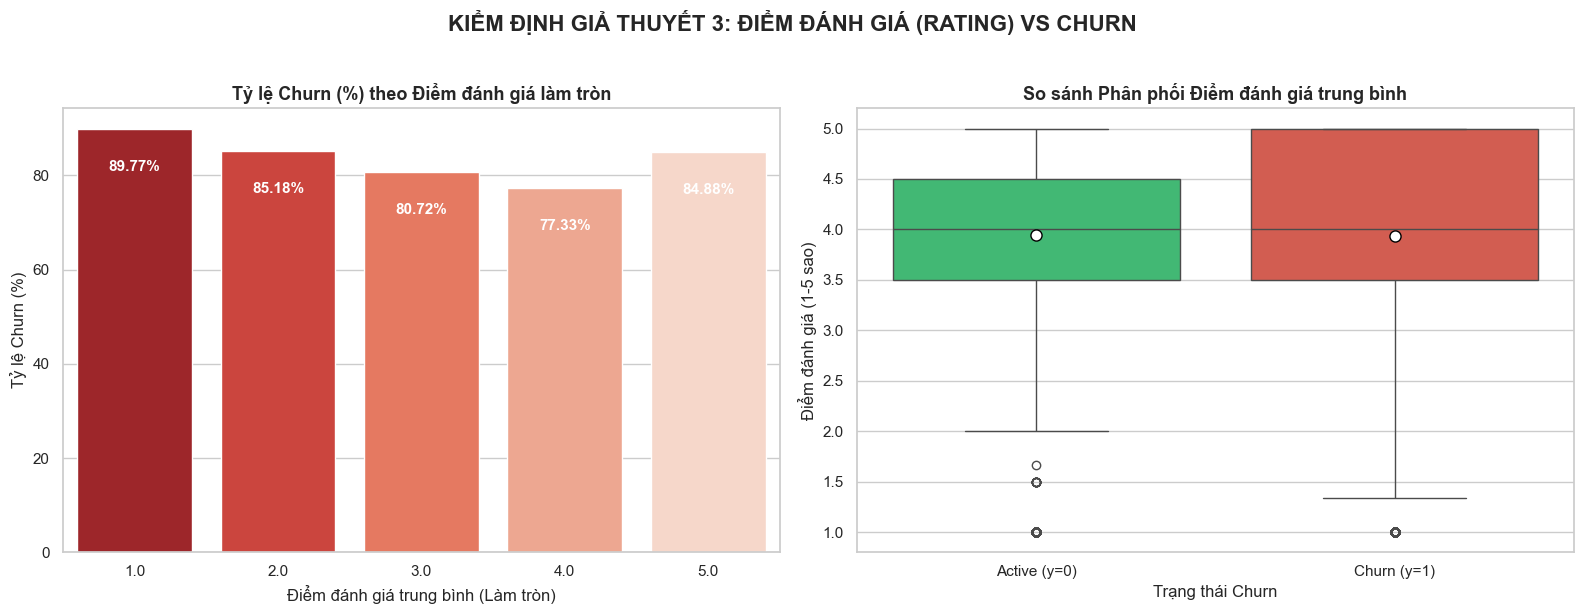

Tỷ lệ Churn phân loại theo điểm đánh giá trung bình làm tròn:


churn_label,Active (y=0),Churn (y=1)
rounded_rating,,
1.0,10.229133,89.770867
2.0,14.821010,85.178990
3.0,19.284406,80.715594
4.0,22.672065,77.327935
5.0,15.117276,84.882724


In [32]:
# --- KIỂM ĐỊNH GIẢ THUYẾT 3: ĐIỂM ĐÁNH GIÁ (RATING) VS CHURN ---
cust_stats_with_reviews = cust_stats[cust_stats['avg_rating'].notna()].copy()
cust_stats_with_reviews['rounded_rating'] = cust_stats_with_reviews['avg_rating'].round()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Tỷ lệ Churn theo điểm đánh giá trung bình làm tròn
churn_by_rating = cust_stats_with_reviews.groupby('rounded_rating')['churn'].mean().reset_index()
churn_by_rating['churn_pct'] = churn_by_rating['churn'] * 100

sns.barplot(
    data=churn_by_rating, x='rounded_rating', y='churn_pct', ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Tỷ lệ Churn (%) theo Điểm đánh giá làm tròn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Điểm đánh giá trung bình (Làm tròn)')
axes[0].set_ylabel('Tỷ lệ Churn (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height() - 8),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 2. So sánh Phân phối Điểm đánh giá trung bình giữa Active vs Churn
sns.boxplot(
    data=cust_stats_with_reviews, x='churn_label', y='avg_rating', ax=axes[1],
    palette={'Active (y=0)': '#2ecc71', 'Churn (y=1)': '#e74c3c'}, showmeans=True,
    meanprops={'marker':'o', 'markerfacecolor':'white', 'markeredgecolor':'black', 'markersize':8}
)
axes[1].set_title('So sánh Phân phối Điểm đánh giá trung bình', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trạng thái Churn')
axes[1].set_ylabel('Điểm đánh giá (1-5 sao)')

plt.suptitle('KIỂM ĐỊNH GIẢ THUYẾT 3: ĐIỂM ĐÁNH GIÁ (RATING) VS CHURN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Tỷ lệ Churn phân loại theo điểm đánh giá trung bình làm tròn:')
display(cust_stats_with_reviews.groupby('rounded_rating')['churn_label'].value_counts(normalize=True).unstack() * 100)

## 6. Nhận xét & Kết luận sơ bộ (EDA Insights)

Dựa vào các biểu đồ và thống kê trên:
1. **Tỷ lệ Churn cực kỳ cao (~86.9%)**: Cho thấy việc giữ chân khách hàng hiện tại của doanh nghiệp đang rất yếu, đa phần mua xong rồi bỏ đi.
2. **Hành vi Recency & Frequency là chỉ báo cốt lõi**:
   - Khách Active có Recency ngắn hơn rõ rệt (trung vị 368 ngày vs 1107 ngày của Churn) và Frequency vượt trội (trung vị 12 đơn vs 3 đơn của Churn).
3. **Giả thuyết 1 (Giao trễ) - Bị bác bỏ ❌**:
   - Thời gian giao trung bình (~4.5 ngày) và tỷ lệ giao trễ (~33%) của nhóm Active và Churn là **gần như giống hệt nhau**. Sự trễ hạn giao hàng không phải nguyên nhân chính thúc đẩy khách rời đi.
4. **Giả thuyết 2 (Trả hàng) - Báo động giả (Paradoxical Correlation) ⚠️**:
   - Khách từng trả hàng có tỷ lệ Churn thấp hơn (76.8% vs 90.7%). Đây là **thiên kiến tần suất (Frequency Bias)**: Khách quen (Active) mua quá nhiều đơn nên xác suất họ có ít nhất 1 đơn hoàn trả sẽ cao hơn nhóm vãng lai chỉ mua 1-2 đơn. Bản chất hành vi trả hàng là dấu hiệu của việc tương tác mạnh mẽ với shop thay vì sự thất vọng.
5. **Giả thuyết 3 (Điểm đánh giá) - Tác động cục bộ ⚠️**:
   - Nhóm đánh giá 4 sao có tỷ lệ Churn thấp nhất (77.3%), trong khi nhóm đánh giá tệ nhất 1 sao có tỷ lệ Churn cao nhất (89.8%).
   - Điểm thú vị: Nhóm 5 sao cũng có tỷ lệ Churn khá cao (84.9%), có thể do đây là nhóm khách hàng mua duy nhất một lần, rất hài lòng với sản phẩm và đánh giá 5 sao nhưng sau đó không có nhu cầu quay lại mua tiếp.